In [2]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.svm import SVC 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report 
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('your_file.csv') 
print(df.head())

   Experience  Education  Age  Salary
0           1         12   22   25000
1           2         12   24   30000
2           3         14   26   38000
3           4         14   28   45000
4           5         15   30   52000


In [7]:
salary=df['Salary']

In [22]:
conditions = [
 salary < 50000,
 (salary >= 50000) & (salary < 80000),
 salary >= 80000
]

In [23]:
choices = [0, 1, 2] 
df['SalaryClass'] = np.select(conditions, choices)

In [26]:
print("Class Distribution:\n", df['SalaryClass'].value_counts())

Class Distribution:
 SalaryClass
0    4
1    4
2    2
Name: count, dtype: int64


In [27]:
X = df[['Experience', 'Education', 'Age']] 
y = df['SalaryClass'] 

In [28]:
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.3, random_state=42, stratify=y 
)

In [29]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [30]:
# SVM Model 
# kernel can be: 'linear', 'rbf', 'poly', 'sigmoid' 
svm = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr') 
svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
y_pred = svm.predict(X_test_scaled) 

In [32]:
acc = accuracy_score(y_test, y_pred)

In [33]:
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0) 
rec_macro  = recall_score(y_test, y_pred, average='macro', zero_division=0) 
f1_macro   = f1_score(y_test, y_pred, average='macro', zero_division=0) 
prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0) 
rec_weighted  = recall_score(y_test, y_pred, average='weighted', zero_division=0) 
f1_weighted   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

In [34]:
print("Accuracy:", acc) 
print("\nMacro Average:") 
print("Precision (Macro):", prec_macro) 
print("Recall (Macro):   ", rec_macro) 
print("F1-score (Macro): ", f1_macro) 
print("\nWeighted Average:") 
print("Precision (Weighted):", prec_weighted) 
print("Recall (Weighted):   ", rec_weighted) 
print("F1-score (Weighted): ", f1_weighted) 

Accuracy: 0.6666666666666666

Macro Average:
Precision (Macro): 0.5
Recall (Macro):    0.6666666666666666
F1-score (Macro):  0.5555555555555555

Weighted Average:
Precision (Weighted): 0.5
Recall (Weighted):    0.6666666666666666
F1-score (Weighted):  0.5555555555555555


In [35]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n", 
classification_report(y_test, y_pred, 
target_names=['Low', 'Medium', 'High'], 
zero_division=0))


Confusion Matrix:
 [[1 0 0]
 [0 1 0]
 [0 1 0]]

Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         1
      Medium       0.50      1.00      0.67         1
        High       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



In [36]:
input_data = [[6, 16, 30]] 
input_scaled = scaler.transform(input_data) 
predicted_class = svm.predict(input_scaled)[0] 
labels = ['Low', 'Medium', 'High'] 
print("\nPredicted Class:", labels[predicted_class])


Predicted Class: Medium


E:\anaconda3\envs\ml_lab\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


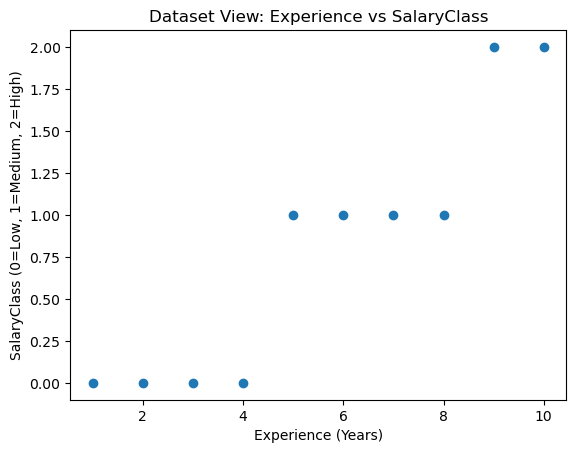

In [37]:
plt.scatter(df['Experience'], df['SalaryClass']) 
plt.xlabel("Experience (Years)") 
plt.ylabel("SalaryClass (0=Low, 1=Medium, 2=High)") 
plt.title("Dataset View: Experience vs SalaryClass") 
plt.show()